# 🧪 Actividad 5 – Entrenamiento, Ajuste y Registro con MLflow
## Gestión de Proyectos de Inteligencia Artificial

**Dataset:** SST-2 (Stanford Sentiment Treebank v2)  
**Tarea:** Clasificación binaria de sentimientos  
**Modelos:** Regresión Logística vs. Random Forest  
**Features:** TF-IDF (unigramas + bigramas)  
**Registro:** MLflow local con UI en Colab


## 1. Instalación de Dependencias

In [1]:
%%capture
!pip install mlflow datasets scikit-learn pandas matplotlib seaborn --quiet

In [2]:
import mlflow, sklearn, pandas as pd, numpy as np
print(f'mlflow      : {mlflow.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'pandas      : {pd.__version__}')
print(f'numpy       : {np.__version__}')

mlflow      : 3.1.4
scikit-learn: 1.6.1
pandas      : 2.3.0+4.g1dfc98e16a
numpy       : 2.0.2


## 2. Configuración de MLflow y apertura de UI

In [3]:
import subprocess, threading, time

MLFLOW_PORT     = 5000
EXPERIMENT_NAME = 'Act5_SST2_Sentiment'

def run_mlflow():
    subprocess.Popen(
        ['mlflow', 'ui', '--port', str(MLFLOW_PORT), '--host', '127.0.0.1'],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

threading.Thread(target=run_mlflow, daemon=True).start()
time.sleep(3)

mlflow.set_tracking_uri(f'http://localhost:{MLFLOW_PORT}')
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'✅ MLflow corriendo en: http://localhost:{MLFLOW_PORT}')
print('   Abre ese link en tu navegador para ver el panel')

2026/06/20 21:53:49 INFO mlflow.tracking.fluent: Experiment with name 'Act5_SST2_Sentiment' does not exist. Creating a new experiment.


✅ MLflow corriendo en: http://localhost:5000
   Abre ese link en tu navegador para ver el panel


## 3. Carga del Dataset SST-2

In [4]:
from datasets import load_dataset

print('📥 Cargando SST-2...')
dataset  = load_dataset('stanfordnlp/sst2')
df_train = dataset['train'].to_pandas()[['sentence', 'label']]
df_val   = dataset['validation'].to_pandas()[['sentence', 'label']]

print(f'Train      : {len(df_train):,} ejemplos')
print(f'Validación : {len(df_val):,} ejemplos')
df_train.head(3)

/opt/anaconda3/envs/MachineLearning/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📥 Cargando SST-2...


Generating test split: 100%|██████████| 1821/1821 [00:00<00:00, 706944.43 examples/s]

Train      : 67,349 ejemplos
Validación : 872 ejemplos


,sentence,label
0,hide new secretions from the parental units,0
1,"contains no wit , only labored gags",0
2,that loves its characters and communicates som...,1


## 4. Limpieza y Estandarización de Datos

In [5]:
import re, os

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-z\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

def preparar_dataset(df, nombre):
    df = df.copy()
    print(f'\n🧹 Limpiando {nombre}...')
    nulos = df.isnull().sum().sum()
    df.dropna(subset=['sentence','label'], inplace=True)
    dups = df.duplicated(subset='sentence').sum()
    df.drop_duplicates(subset='sentence', inplace=True)
    df['sentence_clean'] = df['sentence'].apply(limpiar_texto)
    vacios = (df['sentence_clean'].str.strip() == '').sum()
    df = df[df['sentence_clean'].str.strip() != '']
    df['num_words'] = df['sentence_clean'].str.split().str.len()
    df['num_chars'] = df['sentence_clean'].str.len()
    df['sentiment'] = df['label'].map({0:'NEGATIVE', 1:'POSITIVE'})
    print(f'   Nulos eliminados     : {nulos}')
    print(f'   Duplicados eliminados: {dups}')
    print(f'   Vacíos eliminados    : {vacios}')
    print(f'   Registros finales    : {len(df):,}')
    return df.reset_index(drop=True)

df_train_clean = preparar_dataset(df_train, 'train')
df_val_clean   = preparar_dataset(df_val,   'validación')

os.makedirs('datos/datos_ini',  exist_ok=True)
os.makedirs('datos/datos_limp', exist_ok=True)
df_train.to_csv('datos/datos_ini/sst2_train_original.csv',     index=False)
df_val.to_csv('datos/datos_ini/sst2_val_original.csv',         index=False)
df_train_clean.to_csv('datos/datos_limp/sst2_train_clean.csv', index=False)
df_val_clean.to_csv('datos/datos_limp/sst2_val_clean.csv',     index=False)
print('\n✅ Archivos guardados en datos/')


🧹 Limpiando train...
   Nulos eliminados     : 0
   Duplicados eliminados: 371
   Vacíos eliminados    : 7
   Registros finales    : 66,971

🧹 Limpiando validación...
   Nulos eliminados     : 0
   Duplicados eliminados: 0
   Vacíos eliminados    : 0
   Registros finales    : 872

✅ Archivos guardados en datos/


## 5. Visualizaciones de Calidad de Datos

/var/folders/00/f9cgjjnn5mn4hzs09c_f2kh00000gq/T/ipykernel_4858/1822904421.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot([neg_w, pos_w], labels=['NEGATIVE','POSITIVE'],
/var/folders/00/f9cgjjnn5mn4hzs09c_f2kh00000gq/T/ipykernel_4858/1822904421.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(null_counts.index, rotation=15, fontsize=8)
/var/folders/00/f9cgjjnn5mn4hzs09c_f2kh00000gq/T/ipykernel_4858/1822904421.py:52: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig('resultados_calidad_datos.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/envs/MachineLearning/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Ar

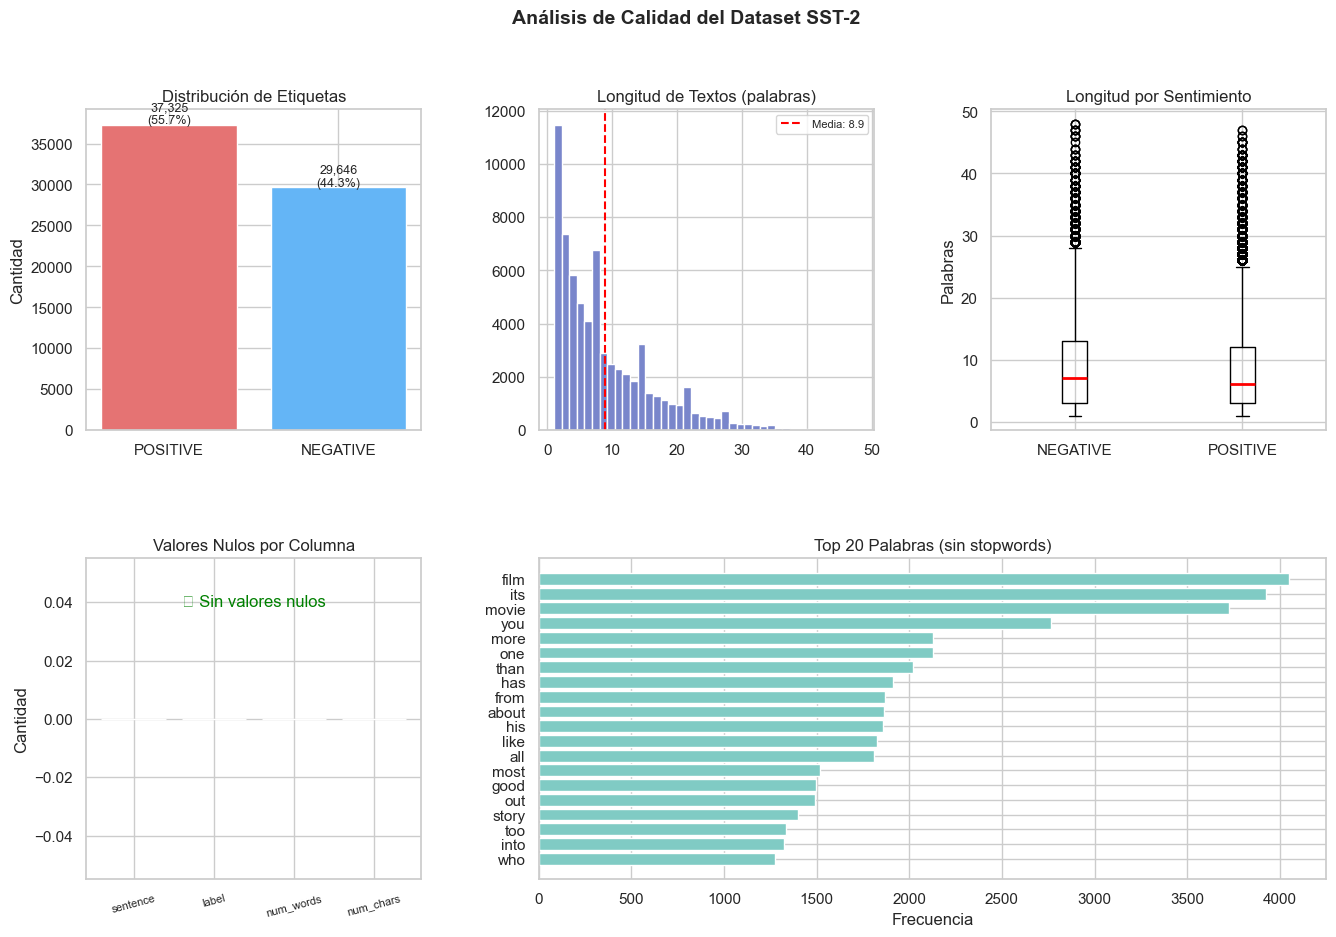

📊 Guardada: resultados_calidad_datos.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Análisis de Calidad del Dataset SST-2', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Distribución de etiquetas
ax1 = fig.add_subplot(gs[0,0])
counts = df_train_clean['sentiment'].value_counts()
ax1.bar(counts.index, counts.values, color=['#E57373','#64B5F6'])
ax1.set_title('Distribución de Etiquetas'); ax1.set_ylabel('Cantidad')
for i, v in enumerate(counts.values):
    ax1.text(i, v+100, f'{v:,}\n({v/len(df_train_clean)*100:.1f}%)', ha='center', fontsize=9)

# 2. Histograma longitud
ax2 = fig.add_subplot(gs[0,1])
ax2.hist(df_train_clean['num_words'], bins=40, color='#7986CB', edgecolor='white')
ax2.axvline(df_train_clean['num_words'].mean(), color='red', linestyle='--',
            label=f'Media: {df_train_clean["num_words"].mean():.1f}')
ax2.set_title('Longitud de Textos (palabras)'); ax2.legend(fontsize=8)

# 3. Boxplot por clase
ax3 = fig.add_subplot(gs[0,2])
neg_w = df_train_clean[df_train_clean['label']==0]['num_words']
pos_w = df_train_clean[df_train_clean['label']==1]['num_words']
ax3.boxplot([neg_w, pos_w], labels=['NEGATIVE','POSITIVE'],
            medianprops=dict(color='red', linewidth=2))
ax3.set_title('Longitud por Sentimiento'); ax3.set_ylabel('Palabras')

# 4. Valores nulos
ax4 = fig.add_subplot(gs[1,0])
null_counts = df_train_clean[['sentence','label','num_words','num_chars']].isnull().sum()
ax4.bar(null_counts.index, null_counts.values, color='#A5D6A7')
ax4.set_title('Valores Nulos por Columna'); ax4.set_ylabel('Cantidad')
ax4.set_xticklabels(null_counts.index, rotation=15, fontsize=8)
ax4.text(0.5, 0.85, '✅ Sin valores nulos', transform=ax4.transAxes, ha='center', color='green')

# 5. Top 20 palabras
ax5 = fig.add_subplot(gs[1,1:])
stopwords = {'the','a','an','and','of','to','is','in','it','that','this','s','was','for','with','as','be','are','but','not','have','on'}
all_words = ' '.join(df_train_clean['sentence_clean']).split()
freq = Counter(w for w in all_words if w not in stopwords and len(w) > 2)
top20 = freq.most_common(20)
words, freqs = zip(*top20)
ax5.barh(list(reversed(words)), list(reversed(freqs)), color='#80CBC4')
ax5.set_title('Top 20 Palabras (sin stopwords)'); ax5.set_xlabel('Frecuencia')

plt.savefig('resultados_calidad_datos.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Guardada: resultados_calidad_datos.png')

## 6. Extracción de Features con TF-IDF

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

TRAIN_SIZE = 5000
SEED       = 42

df_sample   = df_train_clean.sample(TRAIN_SIZE, random_state=SEED).reset_index(drop=True)
X_train_raw = df_sample['sentence_clean'].values
y_train     = df_sample['label'].values
X_val_raw   = df_val_clean['sentence_clean'].values
y_val       = df_val_clean['label'].values

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
X_train = tfidf.fit_transform(X_train_raw)
X_val   = tfidf.transform(X_val_raw)

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'Vocab   : {len(tfidf.vocabulary_):,} términos')

X_train : (5000, 10000)
X_val   : (872, 10000)
Vocab   : 10,000 términos


## 7. Entrenamiento y Grid Search (5-fold CV)
### 7.1 Regresión Logística

In [9]:
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics         import (accuracy_score, precision_score, recall_score,
                                      f1_score, roc_auc_score, classification_report)
import time, joblib

os.makedirs('modelos', exist_ok=True)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

param_grid_lr = {'C':[0.01,0.1,1.0,10.0], 'solver':['lbfgs','liblinear'], 'max_iter':[300]}

print('🔍 Grid Search — Regresión Logística (5-fold CV)...')
t0    = time.time()
gs_lr = GridSearchCV(LogisticRegression(random_state=SEED),
                     param_grid_lr, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
gs_lr.fit(X_train, y_train)
t_lr    = time.time() - t0
best_lr = gs_lr.best_estimator_
print(f'✅ {t_lr:.1f}s | Mejor params: {gs_lr.best_params_} | CV F1: {gs_lr.best_score_:.4f}')

🔍 Grid Search — Regresión Logística (5-fold CV)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ 1.9s | Mejor params: {'C': 10.0, 'max_iter': 300, 'solver': 'lbfgs'} | CV F1: 0.8136


In [10]:
y_pred_lr = best_lr.predict(X_val)
y_prob_lr = best_lr.predict_proba(X_val)[:,1]
metrics_lr = {
    'accuracy':accuracy_score(y_val,y_pred_lr),
    'precision':precision_score(y_val,y_pred_lr,zero_division=0),
    'recall':recall_score(y_val,y_pred_lr,zero_division=0),
    'f1':f1_score(y_val,y_pred_lr,zero_division=0),
    'roc_auc':roc_auc_score(y_val,y_prob_lr),
    'cv_f1':gs_lr.best_score_,
    'train_time_s':t_lr
}
print('Regresión Logística — Validación')
for k,v in metrics_lr.items(): print(f'  {k:<16}: {v:.4f}')
print()
print(classification_report(y_val, y_pred_lr, target_names=['Negativo','Positivo']))
joblib.dump(best_lr,'modelos/logistic_regression.pkl')
print('✅ Modelo guardado')

Regresión Logística — Validación
  accuracy        : 0.7638
  precision       : 0.7644
  recall          : 0.7748
  f1              : 0.7696
  roc_auc         : 0.8486
  cv_f1           : 0.8136
  train_time_s    : 1.9443

              precision    recall  f1-score   support

    Negativo       0.76      0.75      0.76       428
    Positivo       0.76      0.77      0.77       444

    accuracy                           0.76       872
   macro avg       0.76      0.76      0.76       872
weighted avg       0.76      0.76      0.76       872

✅ Modelo guardado


### 7.2 Random Forest

In [11]:
param_grid_rf = {'n_estimators':[100,200], 'max_depth':[None,20], 'min_samples_split':[2,5]}

print('🔍 Grid Search — Random Forest (5-fold CV)...')
t0    = time.time()
gs_rf = GridSearchCV(RandomForestClassifier(random_state=SEED),
                     param_grid_rf, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
gs_rf.fit(X_train, y_train)
t_rf    = time.time() - t0
best_rf = gs_rf.best_estimator_
print(f'✅ {t_rf:.1f}s | Mejor params: {gs_rf.best_params_} | CV F1: {gs_rf.best_score_:.4f}')

🔍 Grid Search — Random Forest (5-fold CV)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ 16.3s | Mejor params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200} | CV F1: 0.7430


In [12]:
y_pred_rf = best_rf.predict(X_val)
y_prob_rf = best_rf.predict_proba(X_val)[:,1]
metrics_rf = {
    'accuracy':accuracy_score(y_val,y_pred_rf),
    'precision':precision_score(y_val,y_pred_rf,zero_division=0),
    'recall':recall_score(y_val,y_pred_rf,zero_division=0),
    'f1':f1_score(y_val,y_pred_rf,zero_division=0),
    'roc_auc':roc_auc_score(y_val,y_prob_rf),
    'cv_f1':gs_rf.best_score_,
    'train_time_s':t_rf
}
print('Random Forest — Validación')
for k,v in metrics_rf.items(): print(f'  {k:<16}: {v:.4f}')
print()
print(classification_report(y_val, y_pred_rf, target_names=['Negativo','Positivo']))
joblib.dump(best_rf,'modelos/random_forest.pkl')
print('✅ Modelo guardado')

Random Forest — Validación
  accuracy        : 0.7179
  precision       : 0.6926
  recall          : 0.8018
  f1              : 0.7432
  roc_auc         : 0.8003
  cv_f1           : 0.7430
  train_time_s    : 16.2658

              precision    recall  f1-score   support

    Negativo       0.75      0.63      0.69       428
    Positivo       0.69      0.80      0.74       444

    accuracy                           0.72       872
   macro avg       0.72      0.72      0.72       872
weighted avg       0.72      0.72      0.72       872

✅ Modelo guardado


## 8. Registro en MLflow

In [14]:
import mlflow.sklearn

def registrar_run(nombre, modelo, param_grid, best_params, metrics, artefacto):
    with mlflow.start_run(run_name=nombre):
        mlflow.log_param('tfidf_max_features', 10000)
        mlflow.log_param('tfidf_ngram_range',  '(1,2)')
        mlflow.log_param('cv_folds',           5)
        mlflow.log_param('train_sample_size',  TRAIN_SIZE)
        mlflow.log_param('random_seed',        SEED)
        mlflow.log_param('grid_search_params', str(param_grid))
        for k,v in best_params.items():
            mlflow.log_param(f'best_{k}', v)
        for k,v in metrics.items():
            mlflow.log_metric(k, v)
        mlflow.sklearn.log_model(modelo, artifact_path='model')
        mlflow.log_artifact(artefacto)
        mlflow.log_artifact('datos/datos_limp/sst2_train_clean.csv')
        mlflow.log_artifact('datos/datos_limp/sst2_val_clean.csv')
        mlflow.log_artifact('resultados_calidad_datos.png')
        run_id = mlflow.active_run().info.run_id
        print(f'  ✅ Run registrado: {run_id}')
        return run_id

print('📋 Registrando en MLflow...')
print('\n► Run 1: Regresión Logística')
run_id_lr = registrar_run('LogisticRegression_GridSearch', best_lr,
                           param_grid_lr, gs_lr.best_params_, metrics_lr,
                           'modelos/logistic_regression.pkl')
print('\n► Run 2: Random Forest')
run_id_rf = registrar_run('RandomForest_GridSearch', best_rf,
                           param_grid_rf, gs_rf.best_params_, metrics_rf,
                           'modelos/random_forest.pkl')
print(f'\n✅ Ambos registrados. Toma captura del panel:')
print(f'   http://localhost:5000')

2026/06/20 21:58:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


📋 Registrando en MLflow...

► Run 1: Regresión Logística


2026/06/20 21:58:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/06/20 21:58:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  ✅ Run registrado: 2873032d67a4489181e82ee4e326c5e4
🏃 View run LogisticRegression_GridSearch at: http://localhost:5000/#/experiments/413832497498238256/runs/2873032d67a4489181e82ee4e326c5e4
🧪 View experiment at: http://localhost:5000/#/experiments/413832497498238256

► Run 2: Random Forest


2026/06/20 21:58:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  ✅ Run registrado: 4881fbe90336444fb5c2bb081601a41e
🏃 View run RandomForest_GridSearch at: http://localhost:5000/#/experiments/413832497498238256/runs/4881fbe90336444fb5c2bb081601a41e
🧪 View experiment at: http://localhost:5000/#/experiments/413832497498238256

✅ Ambos registrados. Toma captura del panel:
   http://localhost:5000


## 9. Comparación Final

In [15]:
df_comp = pd.DataFrame({'Regresión Logística':metrics_lr,'Random Forest':metrics_rf}).T.round(4)
print('='*60)
print('COMPARACIÓN FINAL DE MODELOS')
print('='*60)
print(df_comp.to_string())
mejor = 'Regresión Logística' if metrics_lr['f1'] >= metrics_rf['f1'] else 'Random Forest'
print(f'\n🏆 Recomendado por F1: {mejor}')

COMPARACIÓN FINAL DE MODELOS
                     accuracy  precision  recall      f1  roc_auc   cv_f1  train_time_s
Regresión Logística    0.7638     0.7644  0.7748  0.7696   0.8486  0.8136        1.9443
Random Forest          0.7179     0.6926  0.8018  0.7432   0.8003  0.7430       16.2658

🏆 Recomendado por F1: Regresión Logística


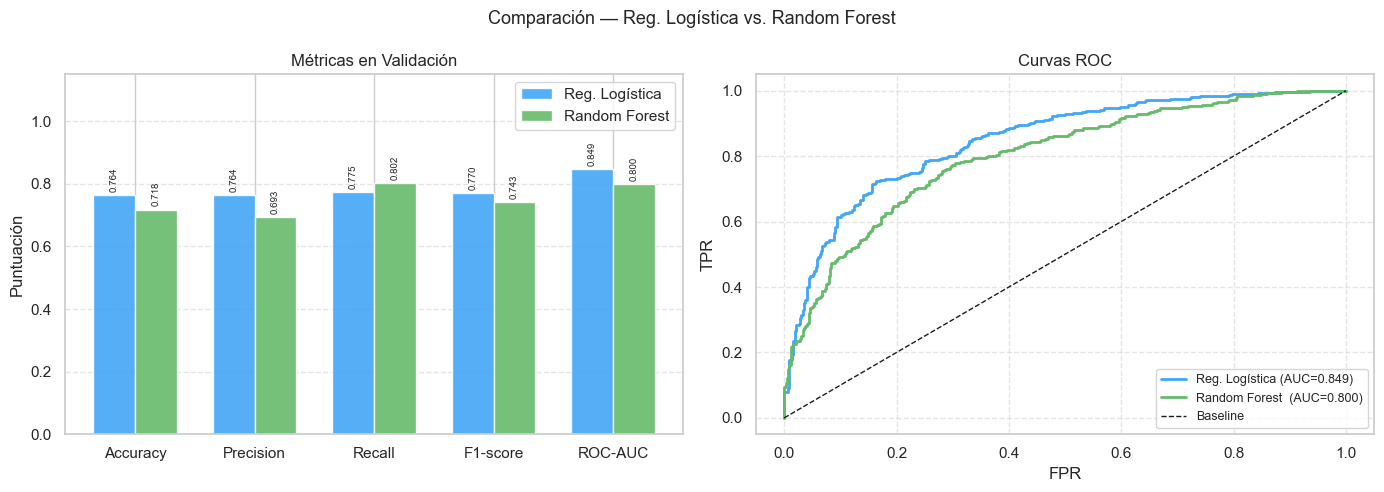

🏃 View run LogisticRegression_GridSearch at: http://localhost:5000/#/experiments/413832497498238256/runs/2873032d67a4489181e82ee4e326c5e4
🧪 View experiment at: http://localhost:5000/#/experiments/413832497498238256
🏃 View run RandomForest_GridSearch at: http://localhost:5000/#/experiments/413832497498238256/runs/4881fbe90336444fb5c2bb081601a41e
🧪 View experiment at: http://localhost:5000/#/experiments/413832497498238256
✅ Gráfica registrada en MLflow.


In [16]:
from sklearn.metrics import roc_curve

metricas = ['accuracy','precision','recall','f1','roc_auc']
labels   = ['Accuracy','Precision','Recall','F1-score','ROC-AUC']
vals_lr  = [metrics_lr[m] for m in metricas]
vals_rf  = [metrics_rf[m] for m in metricas]
x, width = np.arange(len(labels)), 0.35

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Comparación — Reg. Logística vs. Random Forest', fontsize=13)

b1 = ax1.bar(x-width/2, vals_lr, width, label='Reg. Logística', color='#42A5F5', alpha=0.9)
b2 = ax1.bar(x+width/2, vals_rf, width, label='Random Forest',  color='#66BB6A', alpha=0.9)
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylim(0,1.15); ax1.set_ylabel('Puntuación')
ax1.set_title('Métricas en Validación'); ax1.legend()
ax1.grid(axis='y',linestyle='--',alpha=0.5)
for bar in [*b1,*b2]:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

for y_prob,name,color in [
    (y_prob_lr, f'Reg. Logística (AUC={metrics_lr["roc_auc"]:.3f})','#42A5F5'),
    (y_prob_rf, f'Random Forest  (AUC={metrics_rf["roc_auc"]:.3f})','#66BB6A')]:
    fpr,tpr,_ = roc_curve(y_val, y_prob)
    ax2.plot(fpr,tpr,color=color,lw=2,label=name)
ax2.plot([0,1],[0,1],'k--',lw=1,label='Baseline')
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.set_title('Curvas ROC'); ax2.legend(fontsize=9)
ax2.grid(linestyle='--',alpha=0.5)

plt.tight_layout()
plt.savefig('resultados_comparacion_final.png', dpi=150, bbox_inches='tight')
plt.show()

for rid in [run_id_lr, run_id_rf]:
    with mlflow.start_run(run_id=rid):
        mlflow.log_artifact('resultados_comparacion_final.png')
print('✅ Gráfica registrada en MLflow.')

## 10. Conclusiones y Deuda Técnica

### Comparación de modelos
- **Regresión Logística** con TF-IDF es altamente competitiva en espacios de alta dimensionalidad. La regularización `C` controla el overfitting.
- **Random Forest** con TF-IDF tiende a ser más lento y puede ser superado por modelos lineales en features dispersos.

### Deuda técnica y MLOps
1. **Versionamiento de datos:** En producción versionar con DVC o almacenar en S3/GCS con hash de integridad.
2. **Pipeline serializado:** El vectorizador TF-IDF debe empaquetarse con el modelo usando `sklearn.Pipeline`.
3. **Monitoreo de deriva:** Implementar Evidently AI o Whylogs para detectar data drift en producción.
4. **CI/CD:** Integrar GitHub Actions para re-entrenamiento automático ante cambios en datos.
5. **Escalabilidad:** Para datasets >100K registros considerar Spark MLlib.

> Reproducible ejecutando todas las celdas en orden con SEED=42.